# Filter overview
In this notebook we demonstrate some more typical filters using an example image showing a nucleus.

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from skimage.io import imread
from skimage import data
from skimage import filters
from skimage import morphology
from scipy.ndimage import convolve, gaussian_laplace
import stackview

If intensity around the nucleus is noise, image segmentation may be hard later on.

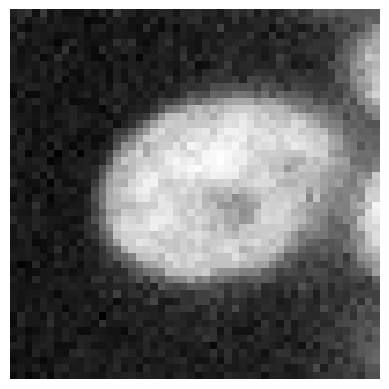

In [2]:
image = imread('data/zebrafish_eye.tif')[504:554, 635:685]

stackview.imshow(image)

## Denoising
Common filters for denoising images are the mean filter, the median filter and the Gaussian filter.

C:\structure\code\embl-bia-2026\.venv\Lib\site-packages\skimage\filters\rank\generic.py:332: UserWarning: Bad rank filter performance is expected due to a large number of bins (56899), equivalent to an approximate bitdepth of 15.8.
  image, footprint, out, mask, n_bins = _preprocess_input(


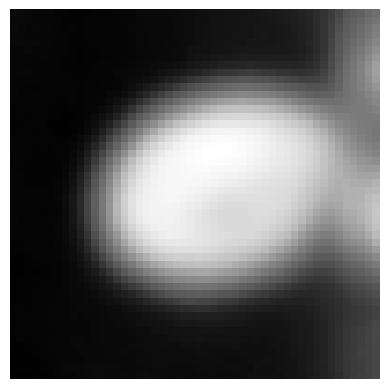

In [3]:
denoised_mean = filters.rank.mean(image, morphology.disk(5))

stackview.imshow(denoised_mean)

The borders of the nucleus are "blurred" and no longer sharp.
Alternatively, we can use the Median-filter which is edge-preserving.

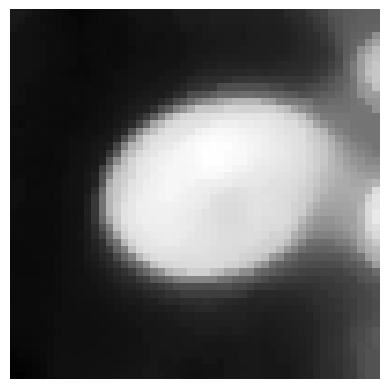

In [4]:
denoised_median = filters.median(image, morphology.disk(5))

stackview.imshow(denoised_median)

If we enter a too wide radius, the structures in the image will be lost.

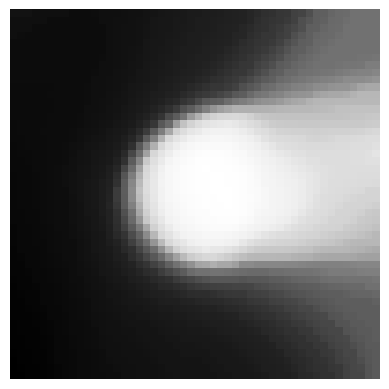

In [5]:
denoised_median2 = filters.median(image, morphology.disk(15))

stackview.imshow(denoised_median2)

We can also show these images side-by-side using matplotlib.

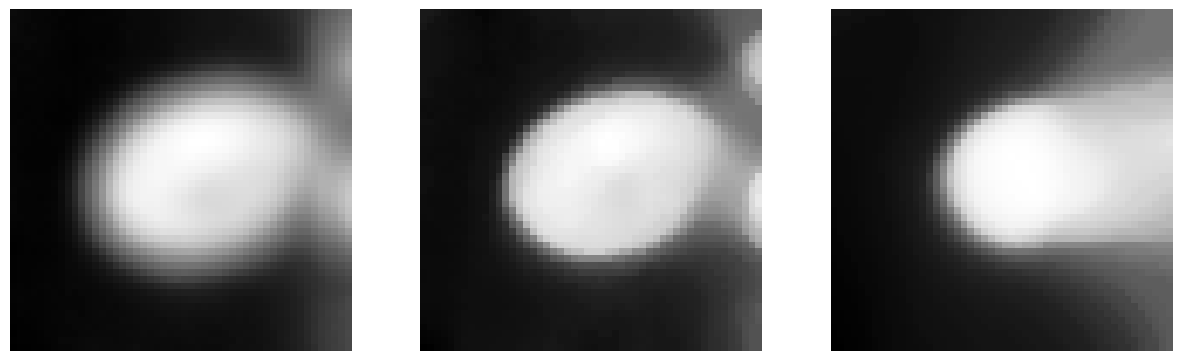

In [6]:
fig, axes = plt.subplots(1,3, figsize=(15,15))

stackview.imshow(denoised_mean, plot=axes[0])
stackview.imshow(denoised_median, plot=axes[1])
stackview.imshow(denoised_median2, plot=axes[2])

To play a bit with such filters, one can setup a small graphical user interface like this:

In [7]:
def median(image, radius:int):
    return filters.median(image, morphology.disk(radius))

stackview.interact(median, image, zoom_factor=8)

## Other filters


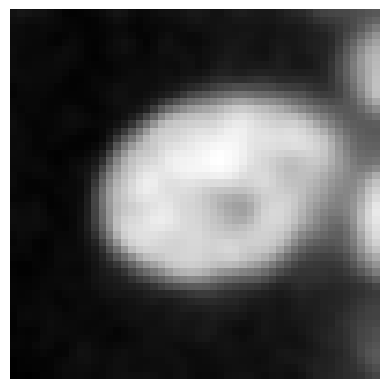

In [8]:
gauss = filters.gaussian(image, sigma=1)

stackview.imshow(gauss)

In [10]:
def gaussian(image, sigma:float):
    return filters.gaussian(image, sigma)

stackview.interact(gaussian, image, zoom_factor=8)

In [ ]:
gradient = filters.rank.gradient(image, morphology.disk(3))

stackview.imshow(gradient)

In [ ]:
sobel = filters.sobel(image)

stackview.imshow(sobel)

## Exercise

Apply a mean filter to the image and a sobel filter to the result of the mean filter afterwards. Try different mean filter radii. Compare the results.